In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
data = pd.read_csv("C:/Users/ASUS/Desktop/FBS/Data science/Dataset/seattleweather1948-2017_1738467795684.csv")
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [71]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [72]:
data.dropna(inplace = True)

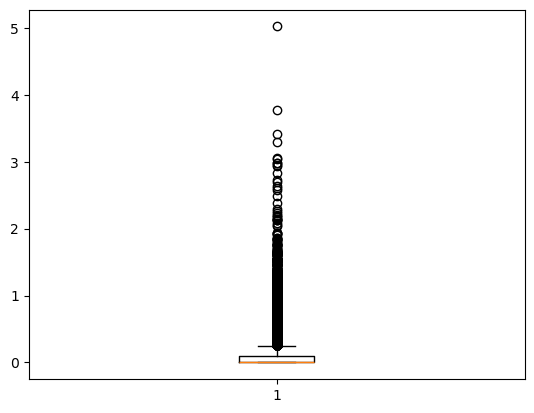

In [73]:
plt.boxplot(data['PRCP'])
plt.show()

In [74]:
def showOutlier(data,column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    return data[(data[column] > upper_bound) | (data[column] < lower_bound)]

In [75]:
showOutlier(data,'PRCP')

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
5,1948-01-06,0.44,48,39,True
...,...,...,...,...,...
25528,2017-11-22,0.52,68,56,True
25534,2017-11-28,0.68,47,43,True
25536,2017-11-30,0.27,46,41,True
25537,2017-12-01,0.27,48,38,True


In [76]:
showOutlier(data,'TMAX')

,DATE,PRCP,TMAX,TMIN,RAIN
743,1950-01-13,1.27,19,11,True
744,1950-01-14,0.16,16,8,True
745,1950-01-15,0.02,21,15,True
761,1950-01-31,0.00,20,0,False
1419,1951-11-20,0.08,4,39,True
2872,1955-11-12,0.00,21,13,False
4603,1960-08-08,0.00,98,66,False
4604,1960-08-09,0.00,99,59,False
6194,1964-12-16,0.00,20,10,False
7167,1967-08-16,0.00,98,59,False


In [77]:
showOutlier(data,'TMIN')

,DATE,PRCP,TMAX,TMIN,RAIN
358,1948-12-24,0.00,36,16,False
374,1949-01-09,0.00,32,13,False
375,1949-01-10,0.00,30,12,False
388,1949-01-23,0.00,30,16,False
393,1949-01-28,0.00,41,16,False
...,...,...,...,...,...
18618,1998-12-22,0.00,29,16,False
22269,2008-12-20,0.16,26,14,True
22624,2009-12-10,0.00,36,16,False
22972,2010-11-23,0.00,25,16,False


In [78]:
def handleOutlier(data,column):
    q3 = data[column].quantile(0.75)
    q1 = data[column].quantile(0.25)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr
    data.loc[(data[column] > upper_bound),column] = upper_bound
    data.loc[(data[column] < upper_bound),column] = lower_bound

In [79]:
handleOutlier(data,'PRCP')

In [80]:
handleOutlier(data,'TMAX')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1256\3112568646.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '97.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[(data[column] > upper_bound),column] = upper_bound


In [81]:
handleOutlier(data,'TMIN')

In [82]:
X = data[['PRCP','TMAX','TMIN']]
X.head()

,PRCP,TMAX,TMIN
0,0.25,21.5,17
1,0.25,21.5,17
2,0.25,21.5,17
3,0.25,21.5,17
4,-0.15,21.5,17


In [83]:
data['RAIN'] = data['RAIN'].replace({True:1,False:0})

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1256\3995751637.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['RAIN'] = data['RAIN'].replace({True:1,False:0})


In [84]:
y = data['RAIN']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: RAIN, dtype: int64

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25548 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25548 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25548 non-null  float64
 3   TMIN    25548 non-null  int64  
 4   RAIN    25548 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 1.2+ MB


In [86]:
from sklearn.model_selection import train_test_split

In [87]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 10)

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
model = LogisticRegression()

In [90]:
model.fit(X_train,y_train)

LogisticRegression()

In [91]:
train_pred = model.predict(X_train)

In [92]:
from sklearn.metrics import accuracy_score

In [93]:
accuracy_score(y_train,train_pred)

0.7188570310206478

In [94]:
test_pred =  model.predict(X_test)

In [95]:
accuracy_score(y_test,test_pred)

0.7136986301369863